In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1: Load model and all dependencies
# ─────────────────────────────────────────────────────────────────────────────
import json, os, re, torch, time, gc
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display, HTML

MODEL_PATH = "/home/lsuryana/.cache/huggingface/hub/Qwen2-VL-7B-Instruct"
print("Loading model...")
model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_PATH, torch_dtype="auto", device_map="cuda")
processor = AutoProcessor.from_pretrained(MODEL_PATH)
print(f"Model loaded. VRAM: {round(torch.cuda.memory_allocated()/1e9,2)} GB")

`Qwen2VLRotaryEmbedding` can now be fully parameterized by passing the model config through the `config` argument. All other arguments will be removed in v4.46


Loading model...


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

Model loaded. VRAM: 16.63 GB


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2: Helper functions and load data + prompts
# ─────────────────────────────────────────────────────────────────────────────

# Load data
with open('results/preprocessed.json') as f:
    data = json.load(f)

# Load prompt templates
p1 = open('prompts/step1_perception.txt').read()
p2 = open('prompts/step2_prediction.txt').read()
p3 = open('prompts/step3_planning.txt').read()
p4 = open('prompts/step4_behavior.txt').read()

# Maps multiple choice letter to action name
CHOICE_MAP = {
    'A': 'KEEP_LANE',
    'B': 'ACCELERATE',
    'C': 'DECELERATE',
    'D': 'CHANGE_LANE_LEFT',
    'E': 'CHANGE_LANE_RIGHT',
    'F': 'STOP'
}

IMAGE_SIZE = (640, 360)

def resize_image(path):
    """Resize image to 640x360 to reduce VRAM usage."""
    tmp = path.replace('.jpg', '_r.jpg')
    if not os.path.exists(tmp):
        img = Image.open(path).convert('RGB').resize(IMAGE_SIZE, Image.LANCZOS)
        img.save(tmp, quality=85)
    return tmp

def run_inference(messages):
    """Run single inference call and free VRAM after."""
    torch.cuda.empty_cache()
    gc.collect()
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True)
    image_inputs, _ = process_vision_info(messages)
    inputs = processor(
        text=[text], images=image_inputs, return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = model.generate(
            **inputs, max_new_tokens=256, temperature=0.0, do_sample=False)
    trimmed = out[:, inputs['input_ids'].shape[1]:]
    result = processor.decode(trimmed[0], skip_special_tokens=True)
    del inputs, out, trimmed
    torch.cuda.empty_cache()
    return result

def parse_step(raw, step):
    """Extract answer for a given step from raw model output."""
    patterns = {
        'perception': r'PERCEPTION:\s*(.*?)$',
        'prediction': r'PREDICTION:\s*(.*?)$',
        'planning':   r'PLANNING:\s*(.*?)$',
        'choice':     r'CHOICE:\s*([A-F])',
        'action':     r'ACTION:\s*(\w+)',
        'reasoning':  r'REASONING:\s*(.*?)$',
    }
    match = re.search(patterns[step], raw, re.DOTALL)
    return match.group(1).strip() if match else ''

def derive_gt_action(traj):
    """Derive GT action from ego trajectory heuristics."""
    x1, x3, y3 = traj[0]['x'], traj[2]['x'], traj[2]['y']
    if abs(x3) < 0.5:   return 'STOP'
    if y3 > 3.0:        return 'CHANGE_LANE_LEFT'
    if y3 < -3.0:       return 'CHANGE_LANE_RIGHT'
    if x1 < 1.5:        return 'DECELERATE'
    if x3 > 12.0:       return 'ACCELERATE'
    return 'KEEP_LANE'

def run_condition(fd, images):
    """
    Run all 4 steps for one condition.
    fd:     frame directory
    images: list of image paths - [t0] for non post-hoc, [t0,t1,t2,t3] for post-hoc
    """
    resized = [resize_image(img) for img in images]

    def img_content():
        return [{"type": "image", "image": p} for p in resized]

    # Step 1: Perception
    msg1 = [{"role": "user", "content": img_content() + [{"type": "text", "text": p1}]}]
    raw1 = run_inference(msg1)
    ans_perc = parse_step(raw1, 'perception') or raw1.strip()

    # Step 2: Prediction
    prompt2 = p2.replace('{PERCEPTION_ANSWER}', ans_perc)
    msg2 = [{"role": "user", "content": img_content() + [{"type": "text", "text": prompt2}]}]
    raw2 = run_inference(msg2)
    ans_pred = parse_step(raw2, 'prediction') or raw2.strip()

    # Step 3: Planning
    prompt3 = p3.replace('{PERCEPTION_ANSWER}', ans_perc)\
                 .replace('{PREDICTION_ANSWER}', ans_pred)
    msg3 = [{"role": "user", "content": img_content() + [{"type": "text", "text": prompt3}]}]
    raw3 = run_inference(msg3)
    ans_plan = parse_step(raw3, 'planning') or raw3.strip()

    # Step 4: Behavior
    prompt4 = p4.replace('{PERCEPTION_ANSWER}', ans_perc)\
                 .replace('{PREDICTION_ANSWER}', ans_pred)\
                 .replace('{PLANNING_ANSWER}', ans_plan)
    msg4 = [{"role": "user", "content": img_content() + [{"type": "text", "text": prompt4}]}]
    raw4 = run_inference(msg4)

    choice    = parse_step(raw4, 'choice')
    action    = CHOICE_MAP.get(choice, 'PARSE_ERROR')
    reasoning = parse_step(raw4, 'reasoning') or raw4.strip()

    return {
        'perception': ans_perc,
        'prediction': ans_pred,
        'planning':   ans_plan,
        'action':     action,
        'choice':     choice,
        'reasoning':  reasoning,
    }

print(f"Loaded {len(data)} samples. Helper functions ready.")

Loaded 24 samples. Helper functions ready.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2b: Updated run_condition using past frames
# Non post-hoc: [past frames] + t0
# Post-hoc:     [past frames] + t0 + t1 + t2 + t3
# ─────────────────────────────────────────────────────────────────────────────

# Reload preprocessed data (now includes past_tokens and n_past)
with open('results/preprocessed.json') as f:
    data = json.load(f)

def get_image_sequence(s, condition):
    """
    Get ordered list of image paths for a sample.
    condition: 'non_posthoc' or 'posthoc'
    
    Non post-hoc: [tm3/tm2] + tm1 + t0          (past + current)
    Post-hoc:     [tm3/tm2] + tm1 + t0 + t1 + t2 + t3  (past + current + future)
    """
    fd = s['frame_dir']
    n_past = s.get('n_past', 0)
    
    # Build past frames list (only include frames that exist)
    past_frames = []
    if n_past >= 3:
        past_frames = [f"{fd}/tm3.jpg", f"{fd}/tm2.jpg", f"{fd}/tm1.jpg"]
    elif n_past == 2:
        past_frames = [f"{fd}/tm2.jpg", f"{fd}/tm1.jpg"]
    elif n_past == 1:
        past_frames = [f"{fd}/tm1.jpg"]

    # Current frame
    current = [f"{fd}/t0.jpg"]

    # Future frames (only for post-hoc)
    future = []
    if condition == 'posthoc':
        future = [f"{fd}/t1.jpg", f"{fd}/t2.jpg", f"{fd}/t3.jpg"]

    return past_frames + current + future

def run_condition_v2(s, condition):
    """
    Run all 4 steps for one condition using past+current (or past+current+future).
    s:         sample dict from preprocessed.json
    condition: 'non_posthoc' or 'posthoc'
    """
    images = get_image_sequence(s, condition)
    resized = [resize_image(img) for img in images]

    n_total = len(images)
    n_past = s.get('n_past', 0)
    print(f"    Images: {n_total} total "
          f"({n_past} past + 1 current"
          f"{' + 3 future' if condition=='posthoc' else ''})")

    def img_content():
        return [{"type": "image", "image": p} for p in resized]

    # Step 1: Perception
    msg1 = [{"role": "user", "content": img_content() + [{"type": "text", "text": p1}]}]
    raw1 = run_inference(msg1)
    ans_perc = parse_step(raw1, 'perception') or raw1.strip()

    # Step 2: Prediction
    prompt2 = p2.replace('{PERCEPTION_ANSWER}', ans_perc)
    msg2 = [{"role": "user", "content": img_content() + [{"type": "text", "text": prompt2}]}]
    raw2 = run_inference(msg2)
    ans_pred = parse_step(raw2, 'prediction') or raw2.strip()

    # Step 3: Planning
    prompt3 = p3.replace('{PERCEPTION_ANSWER}', ans_perc)\
                 .replace('{PREDICTION_ANSWER}', ans_pred)
    msg3 = [{"role": "user", "content": img_content() + [{"type": "text", "text": prompt3}]}]
    raw3 = run_inference(msg3)
    ans_plan = parse_step(raw3, 'planning') or raw3.strip()

    # Step 4: Behavior
    prompt4 = p4.replace('{PERCEPTION_ANSWER}', ans_perc)\
                 .replace('{PREDICTION_ANSWER}', ans_pred)\
                 .replace('{PLANNING_ANSWER}', ans_plan)
    msg4 = [{"role": "user", "content": img_content() + [{"type": "text", "text": prompt4}]}]
    raw4 = run_inference(msg4)

    choice    = parse_step(raw4, 'choice')
    action    = CHOICE_MAP.get(choice, 'PARSE_ERROR')
    reasoning = parse_step(raw4, 'reasoning') or raw4.strip()

    return {
        'perception': ans_perc,
        'prediction': ans_pred,
        'planning':   ans_plan,
        'action':     action,
        'choice':     choice,
        'reasoning':  reasoning,
        'n_images':   n_total,
    }

print("Updated run_condition_v2 ready.")
print("\nImage sequences for sample 7:")
s7 = data[7]
print(f"  Non post-hoc: {get_image_sequence(s7, 'non_posthoc')}")
print(f"  Post-hoc:     {get_image_sequence(s7, 'posthoc')}")

Updated run_condition_v2 ready.

Image sequences for sample 7:
  Non post-hoc: ['cache/frames/c5f58c19249d4137ae063b0e9ecd8b8e/tm2.jpg', 'cache/frames/c5f58c19249d4137ae063b0e9ecd8b8e/tm1.jpg', 'cache/frames/c5f58c19249d4137ae063b0e9ecd8b8e/t0.jpg']
  Post-hoc:     ['cache/frames/c5f58c19249d4137ae063b0e9ecd8b8e/tm2.jpg', 'cache/frames/c5f58c19249d4137ae063b0e9ecd8b8e/tm1.jpg', 'cache/frames/c5f58c19249d4137ae063b0e9ecd8b8e/t0.jpg', 'cache/frames/c5f58c19249d4137ae063b0e9ecd8b8e/t1.jpg', 'cache/frames/c5f58c19249d4137ae063b0e9ecd8b8e/t2.jpg', 'cache/frames/c5f58c19249d4137ae063b0e9ecd8b8e/t3.jpg']



Sample 1: 6dabc0fb1df0...
GT action: STOP


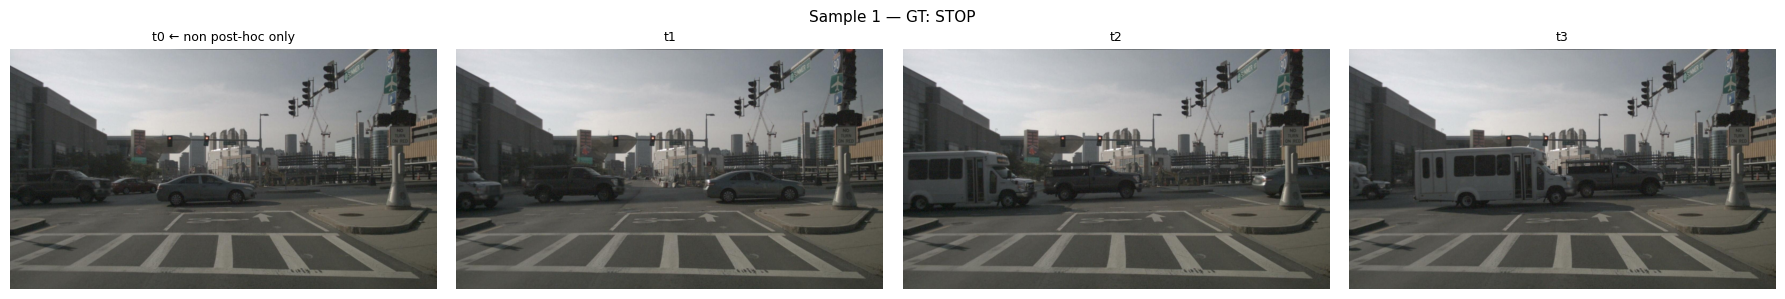


Running NON POST-HOC (t0 only, 4 steps)...


/home/lsuryana/miniconda3/envs/rq2/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/lsuryana/miniconda3/envs/rq2/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/lsuryana/miniconda3/envs/rq2/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:650: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


Done in 22.8s → ACTION: STOP
Running POST-HOC (t0+t1+t2+t3, 4 steps)...
Done in 23.5s → ACTION: STOP
Saved to results/smoke_test_v2_outputs.json



Sample 8: c5f58c19249d...
GT action: ACCELERATE


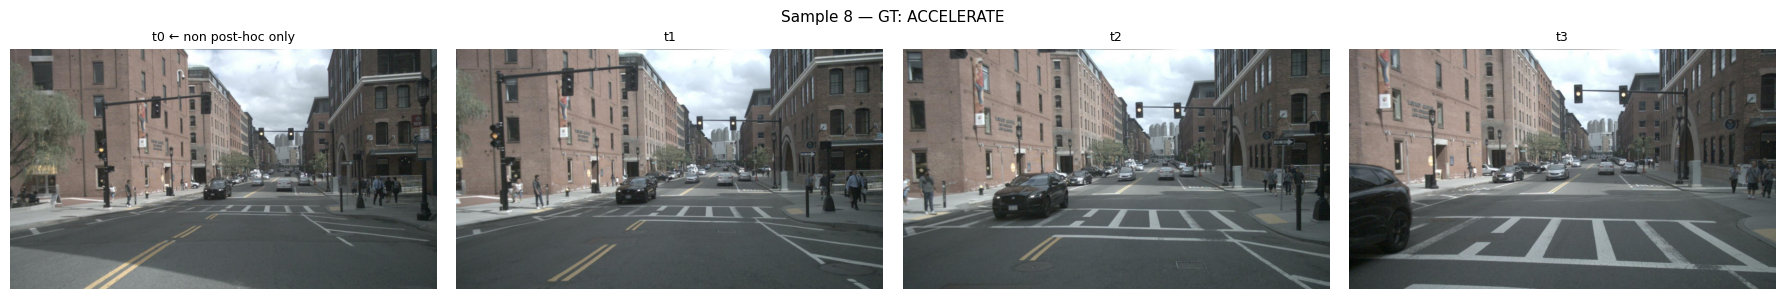


Running NON POST-HOC (t0 only, 4 steps)...
Done in 23.2s → ACTION: STOP
Running POST-HOC (t0+t1+t2+t3, 4 steps)...


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3: Smoke test — run 4-step inference on 2 samples + save results
# Sample 0: stationary (scene-0553, GT=STOP)
# Sample 7: moving     (scene-0916, GT=ACCELERATE)
# ─────────────────────────────────────────────────────────────────────────────

smoke_results = []

for SAMPLE_IDX in [0, 7]:
    s = data[SAMPLE_IDX]
    fd   = s['frame_dir']
    traj = s['trajectory']
    gt   = derive_gt_action(traj)

    print(f"\n{'='*60}")
    print(f"Sample {SAMPLE_IDX+1}: {s['sample_token'][:12]}...")
    print(f"GT action: {gt}")

    # Show images
    fig, axes = plt.subplots(1, 4, figsize=(18, 3))
    for i, ax in enumerate(axes):
        ax.imshow(Image.open(f"{fd}/t{i}.jpg"))
        ax.set_title(f"t{i}" + (" ← non post-hoc only" if i==0 else ""), fontsize=9)
        ax.axis('off')
    plt.suptitle(f"Sample {SAMPLE_IDX+1} — GT: {gt}", fontsize=11)
    plt.tight_layout()
    plt.show()

    # Run non post-hoc
    print("\nRunning NON POST-HOC (t0 only, 4 steps)...")
    t0 = time.time()
    out_non = run_condition(fd, [f"{fd}/t0.jpg"])
    print(f"Done in {time.time()-t0:.1f}s → ACTION: {out_non['action']}")

    # Run post-hoc
    print("Running POST-HOC (t0+t1+t2+t3, 4 steps)...")
    t0 = time.time()
    out_post = run_condition(fd, [f"{fd}/t0.jpg", f"{fd}/t1.jpg",
                                   f"{fd}/t2.jpg", f"{fd}/t3.jpg"])
    print(f"Done in {time.time()-t0:.1f}s → ACTION: {out_post['action']}")

    # Save result
    smoke_results.append({
        'sample_idx':   SAMPLE_IDX,
        'sample_token': s['sample_token'],
        'gt_action':    gt,
        'trajectory':   traj,
        'non_posthoc':  out_non,
        'posthoc':      out_post,
    })

    # Save to file after each sample
    with open('results/smoke_test_v2_outputs.json', 'w') as f:
        json.dump(smoke_results, f, indent=2)
    print(f"Saved to results/smoke_test_v2_outputs.json")

    # Display comparison table
    display(HTML(f"""
    <table style="width:100%; border-collapse:collapse; font-size:12px; font-family:monospace;">
    <tr style="background:#f0f0f0;">
        <th style="padding:8px; border:1px solid #ccc; width:15%;">Step</th>
        <th style="padding:8px; border:1px solid #ccc; width:42.5%;">NON POST-HOC (t0 only)</th>
        <th style="padding:8px; border:1px solid #ccc; width:42.5%;">POST-HOC (t0+t1+t2+t3)</th>
    </tr>
    <tr>
        <td style="padding:8px; border:1px solid #ccc; font-weight:bold;">Perception</td>
        <td style="padding:8px; border:1px solid #ccc; vertical-align:top;">{out_non['perception'][:300]}...</td>
        <td style="padding:8px; border:1px solid #ccc; vertical-align:top;">{out_post['perception'][:300]}...</td>
    </tr>
    <tr style="background:#fafafa;">
        <td style="padding:8px; border:1px solid #ccc; font-weight:bold;">Prediction</td>
        <td style="padding:8px; border:1px solid #ccc; vertical-align:top;">{out_non['prediction'][:300]}...</td>
        <td style="padding:8px; border:1px solid #ccc; vertical-align:top;">{out_post['prediction'][:300]}...</td>
    </tr>
    <tr>
        <td style="padding:8px; border:1px solid #ccc; font-weight:bold;">Planning</td>
        <td style="padding:8px; border:1px solid #ccc; vertical-align:top;">{out_non['planning'][:300]}...</td>
        <td style="padding:8px; border:1px solid #ccc; vertical-align:top;">{out_post['planning'][:300]}...</td>
    </tr>
    <tr style="background:#fafafa;">
        <td style="padding:8px; border:1px solid #ccc; font-weight:bold;">Action</td>
        <td style="padding:8px; border:1px solid #ccc; text-align:center;">
            <span style="font-size:14px; font-weight:bold; color:{'green' if out_non['action']==gt else 'red'};">
            {out_non['action']}</span><br>
            <small>{out_non['reasoning'][:150]}</small>
        </td>
        <td style="padding:8px; border:1px solid #ccc; text-align:center;">
            <span style="font-size:14px; font-weight:bold; color:{'green' if out_post['action']==gt else 'red'};">
            {out_post['action']}</span><br>
            <small>{out_post['reasoning'][:150]}</small>
        </td>
    </tr>
    <tr style="background:#f0f0f0;">
        <td colspan="3" style="padding:8px; border:1px solid #ccc; text-align:center;">
            <b>GT ACTION: {gt}</b> &nbsp;|&nbsp;
            <b>Action changed?</b> {'<span style="color:orange;">YES ⚠</span>' if out_non['action'] != out_post['action'] else '<span style="color:green;">NO ✓</span>'}
        </td>
    </tr>
    </table>
    """))

print(f"\n{'='*60}")
print(f"Smoke test complete. {len(smoke_results)} samples saved.")
print(f"File: results/smoke_test_v2_outputs.json")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4: Full inference — all 24 samples
# Only run this after smoke test (Cell 3) looks correct
# Saves checkpoint after every sample — safe to interrupt and resume
# Output: results/inference_outputs_v2.json
# ─────────────────────────────────────────────────────────────────────────────

CHECKPOINT_FILE = 'results/inference_checkpoint_v2.json'
OUTPUT_FILE     = 'results/inference_outputs_v2.json'

# Load checkpoint if exists (resume from interruption)
done_tokens = set()
results = []
if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE) as f:
        results = json.load(f)
    done_tokens = {r['sample_token'] for r in results}
    print(f"Resuming from checkpoint: {len(done_tokens)}/24 done")
else:
    print("Starting fresh run...")

total_start = time.time()

for idx, s in enumerate(data):
    if s['sample_token'] in done_tokens:
        print(f"[{idx+1}/24] Skipping {s['sample_token'][:8]}... (already done)")
        continue

    fd   = s['frame_dir']
    traj = s['trajectory']
    gt   = derive_gt_action(traj)

    print(f"\n[{idx+1}/24] {s['sample_token'][:8]}... GT={gt}")

    # Show images
    fig, axes = plt.subplots(1, 4, figsize=(16, 2.5))
    for i, ax in enumerate(axes):
        ax.imshow(Image.open(f"{fd}/t{i}.jpg"))
        ax.set_title(f"t{i}", fontsize=8)
        ax.axis('off')
    plt.suptitle(f"[{idx+1}/24] GT: {gt}", fontsize=9)
    plt.tight_layout()
    plt.show()

    # Non post-hoc
    print(f"  NON POST-HOC...", end=' ')
    t0 = time.time()
    out_non = run_condition(fd, [f"{fd}/t0.jpg"])
    print(f"{time.time()-t0:.1f}s → {out_non['action']}")

    # Post-hoc
    print(f"  POST-HOC...", end=' ')
    t0 = time.time()
    out_post = run_condition(fd, [f"{fd}/t0.jpg", f"{fd}/t1.jpg",
                                   f"{fd}/t2.jpg", f"{fd}/t3.jpg"])
    print(f"{time.time()-t0:.1f}s → {out_post['action']}")

    # Save result
    results.append({
        'sample_token': s['sample_token'],
        'scene_token':  s['scene_token'],
        'gt_action':    gt,
        'trajectory':   traj,
        'non_posthoc':  out_non,
        'posthoc':      out_post,
    })

    # Checkpoint after every sample
    with open(CHECKPOINT_FILE, 'w') as f:
        json.dump(results, f, indent=2)

    # Quick inline comparison
    action_changed = out_non['action'] != out_post['action']
    display(HTML(f"""
    <div style="font-family:monospace; font-size:12px; padding:8px;
                border-left:3px solid {'orange' if action_changed else 'green'};
                margin-bottom:8px;">
        <b>NON:</b> <span style="color:{'green' if out_non['action']==gt else 'red'}">
        {out_non['action']}</span> &nbsp;|&nbsp;
        <b>POST:</b> <span style="color:{'green' if out_post['action']==gt else 'red'}">
        {out_post['action']}</span> &nbsp;|&nbsp;
        <b>GT:</b> {gt} &nbsp;|&nbsp;
        {'<b style="color:orange;">CHANGED ⚠</b>' if action_changed else '<b style="color:green;">SAME ✓</b>'}
    </div>
    """))

# Save final output
with open(OUTPUT_FILE, 'w') as f:
    json.dump(results, f, indent=2)

total_time = time.time() - total_start
n = len(results)
change_rate = sum(1 for r in results if r['non_posthoc']['action'] != r['posthoc']['action']) / n
acc_non  = sum(1 for r in results if r['non_posthoc']['action'] == r['gt_action']) / n
acc_post = sum(1 for r in results if r['posthoc']['action']    == r['gt_action']) / n

print(f"\n{'='*50}")
print(f"DONE — {n} samples in {total_time/60:.1f} minutes")
print(f"Non post-hoc accuracy : {acc_non:.3f}")
print(f"Post-hoc accuracy     : {acc_post:.3f}")
print(f"Change rate           : {change_rate:.3f}")
print(f"Saved to              : {OUTPUT_FILE}")